In [ ]:
print('訓練之前載入套件')
print('1-X與y資料準備')
print('2-資料切割')
from sklearn.model_selection import train_test_split
print('3-產生模型物件：各種模型')
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
print('3-整體學習')
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.ensemble import GradientBoostingClassifier
# from sklearn.ensemble import AdaBoostClassifier
# from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import VotingClassifier

訓練之前載入套件
1-X與y資料準備
2-資料切割
3-產生模型物件：各種模型
3-整體學習


In [ ]:
print('建立起模型清單1：')
clf_list = [('KNN',KNeighborsClassifier()),
            ('DecisionTree1',DecisionTreeClassifier()),
            ('DecisionTree2',DecisionTreeClassifier(max_depth=3)),
            ('GaussianNB',GaussianNB()),
            ('LogisticRegression',LogisticRegression(solver='liblinear',max_iter=100)),
            ('MultinomialNB',MultinomialNB())]
            # ('SVC_linear',SVC(kernel='linear',C=0.5,gamma='scale',probability=True)),
            # ('SVC_rbf',SVC(kernel='rbf',C=0.5,gamma='scale',probability=True)),

print('建立起模型清單2：Voting Classifier')
clf_list2 = [('hard vote',VotingClassifier(clf_list, voting='hard')),
             ('soft vote',VotingClassifier(clf_list, voting='soft'))]

建立起模型清單1：
建立起模型清單2：Voting Classifier


In [ ]:
import pandas as pd
import jieba
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
import joblib

c:\Users\yjche\AppData\Local\Programs\Python\Python311\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
# 1️⃣ 讀取已平衡化的資料集
df = pd.read_csv("run_results/ltn1_sentiment1_balanced.csv").dropna(subset=["title", "class"])

# 2️⃣ 斷詞處理
df["cut_title"] = df["title"].apply(lambda x: " ".join(jieba.cut(str(x))))

# 扣除 國際 和 社會 的標籤
# df = df[df["class"].isin(["生活", "財經", "政治"])]

# 3️⃣ 建立 LabelEncoder 並編碼 class
le = LabelEncoder()
df["label"] = le.fit_transform(df["class"])

# 4️⃣ 將 LabelEncoder 儲存成 joblib 檔案
joblib.dump(le, "model_files/label_encoder.joblib")  # 儲存至 model_files 資料夾

# 5️⃣ 查看 index 與 class 對應
label_class_mapping = dict(zip(le.transform(le.classes_), le.classes_))
print("Index -> Class 對應:", label_class_mapping)

# 6. 顯示結果
print("\n整理後類別數量：")
print(df["class_processed"].value_counts())
print(f"總數量: {len(df)}")

# print(df.head(3))
df.to_csv('run_results/ltn1_sen_fit.csv', index=False, encoding='utf-8-sig')

vectorizer = TfidfVectorizer(max_features=40000)  # 初始化 TfidfVectorizer：用於將文本資料轉換為 TF-IDF 特徵向量的工具
# print("實際詞彙數:", len(vectorizer.get_feature_names_out()))

X = vectorizer.fit_transform(df["cut_title"])    # 將斷詞後的 "cut_title" 欄位轉換為 TF-IDF 特徵矩陣
# print(X)
y = df["label"]
joblib.dump(vectorizer, "model_files/tfidf_vectorizer.joblib")

Index -> Class 對應: {0: '健康', 1: '政治', 2: '生活', 3: '財經'}

整理後類別數量：
class_processed
健康    10000
政治    10000
生活    10000
財經    10000
Name: count, dtype: int64
總數量: 40000


['model_files/tfidf_vectorizer.joblib']

In [ ]:
print('4-模型物件開始進行訓練')
print('5-模型儲存')
print('6-模型載入')
import joblib
print('7-模型進行預估')
print('8-模型進行評估')
from sklearn.metrics import accuracy_score #準確率
from sklearn.metrics import classification_report #分類報告
from sklearn.metrics import confusion_matrix #混淆矩陣
from scipy.sparse import issparse # 檢查是否為稀疏矩陣

4-模型物件開始進行訓練
5-模型儲存
6-模型載入
7-模型進行預估
8-模型進行評估


In [ ]:
print('各種模型進行訓練與預測')
print('1-X與y資料準備')
print('2-資料切割')
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y   # 按 y 的分布進行分層切分
)
print(type(X_train))

各種模型進行訓練與預測
1-X與y資料準備
2-資料切割
<class 'scipy.sparse._csr.csr_matrix'>


In [ ]:
# 僅用於 SVC 模型
"""
import pandas as pd
from sklearn.model_selection import train_test_split
from scipy.sparse import vstack

# X 是 csr_matrix，y 是 Series
df_y = pd.DataFrame({'class': y})

# 每個類別取 150 筆，保存索引
sampled_idx = df_y.groupby('class', group_keys=False).apply(lambda x: x.sample(150, random_state=42)).index

# 用稀疏矩陣的索引抽樣
X_subset = X[sampled_idx]
y_subset = y.iloc[sampled_idx]

# 分割時加 stratify
X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset, test_size=0.3, random_state=42, stratify=y_subset
)
"""
print("X_train 型態:", type(X_train))  # <class 'scipy.sparse._csr.csr_matrix'>
print("X_train 形狀:", X_train.shape)
print("X_test 形狀:", X_test.shape)

print("\n各 class 在 y_train 的數量分布：")
print(y_train.value_counts().sort_index())

print("\n各 class 在 y_test 的數量分布：")
print(y_test.value_counts().sort_index())


X_train 型態: <class 'scipy.sparse._csr.csr_matrix'>
X_train 形狀: (28000, 40000)
X_test 形狀: (12000, 40000)

各 class 在 y_train 的數量分布：
label
0    7000
1    7000
2    7000
3    7000
Name: count, dtype: int64

各 class 在 y_test 的數量分布：
label
0    3000
1    3000
2    3000
3    3000
Name: count, dtype: int64


## 1. 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def train_and_evaluate_model(model_tuple, X_train, y_train, X_test, y_test):
    """
    訓練、儲存、載入並評估單個分類模型。
    Args:
        model_tuple (tuple): 包含模型名稱 (str) 和模型物件的元組。
        X_train (array-like): 訓練資料的特徵。 y_train (array-like): 訓練資料的標籤。
        X_test (array-like): 測試資料的特徵。  y_test (array-like): 測試資料的標籤。
    """
    model_name = model_tuple[0]
    model = model_tuple[1]

    print('Model name:', model_name)
    print('3-產生模型物件')

    print('4-模型物件開始進行訓練')
    if issparse(X_train):
        X_train_dense = X_train.toarray()
        model.fit(X_train_dense, y_train)
    else:
        model.fit(X_train, y_train)

    filename = f'model_files/{model_name}.joblib'
    print('5-模型儲存')
    joblib.dump(model, filename)
    print('6-模型載入')
    loaded_model = joblib.load(filename)

    print('7-模型進行預估')
    # predict1 = loaded_model.predict(X_test)
    # predict2 = loaded_model.predict(X_train)
    # 將稀疏矩陣轉換為稠密矩陣
    if issparse(X_test):
        X_test_dense = X_test.toarray()
        predict1 = loaded_model.predict(X_test_dense)
    else:
        predict1 = loaded_model.predict(X_test)

    # 訓練集的預估也需要轉換（雖然錯誤通常出現在測試集）
    if issparse(X_train):
        predict2 = loaded_model.predict(X_train.toarray())
    else:
        predict2 = loaded_model.predict(X_train)

    print('8-模型進行評估')
    print('訓練的準確率\n', accuracy_score(y_train, predict2))
    print('測試的準確率\n', accuracy_score(y_test, predict1))
    print('分類報告\n', classification_report(y_test, predict1))
    print('混淆矩陣\n', confusion_matrix(y_test, predict1))

    # ---- 畫混淆矩陣圖 ----
    cm = confusion_matrix(y_test, predict1)
    plt.figure(figsize=(8,6))
    
    # 設定中文顯示（Windows）
    plt.rcParams['font.family'] = 'Microsoft JhengHei'
    plt.rcParams['axes.unicode_minus'] = False

    # 載入 LabelEncoder
    label_encoder = joblib.load("model_files/label_encoder.joblib")
    class_names = label_encoder.classes_  # 取得原始類別名稱

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)  # fmt='d' 表示整數
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


# 模型列表
clf_list = [('KNN', KNeighborsClassifier()),
            ('DecisionTree1', DecisionTreeClassifier()),
            ('DecisionTree2', DecisionTreeClassifier(max_depth=3)),
            ('SVC_linear', SVC(kernel='linear', C=0.5, gamma='scale', probability=True)),
            ('SVC_rbf', SVC(kernel='rbf', C=0.5, gamma='scale', probability=True)),
            ('GaussianNB', GaussianNB()),
            ('LogisticRegression', LogisticRegression(solver='liblinear', max_iter=100)),
            ('MultinomialNB', MultinomialNB())]

# for model_info in clf_list:  # 使用 for 迴圈逐次將 clf_list 中的元素作為輸入資料帶入函數
#     train_and_evaluate_model(model_info, X_train, y_train, X_test, y_test)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB

params = {'alpha': [0.01, 0.05, 0.06, 0.08, 0.1, 0.2, 0.5]}
grid = GridSearchCV(MultinomialNB(), param_grid=params, cv=5)
grid.fit(X_train, y_train)

print("Best alpha:", grid.best_params_)
print("CV Accuracy:", grid.best_score_)  # 交叉驗證的準確率

Best alpha: {'alpha': 0.2}
CV Accuracy: 0.8914642857142857


Model name: MultinomialNB
3-產生模型物件
4-模型物件開始進行訓練
5-模型儲存
6-模型載入
7-模型進行預估
8-模型進行評估
訓練的準確率
 0.9619285714285715
測試的準確率
 0.8925833333333333
分類報告
               precision    recall  f1-score   support

           0       0.94      0.93      0.94      3000
           1       0.88      0.91      0.89      3000
           2       0.83      0.84      0.84      3000
           3       0.92      0.89      0.90      3000

    accuracy                           0.89     12000
   macro avg       0.89      0.89      0.89     12000
weighted avg       0.89      0.89      0.89     12000

混淆矩陣
 [[2802   11  165   22]
 [  18 2719  169   94]
 [ 121  217 2531  131]
 [  30  130  181 2659]]


<Figure size 800x600 with 0 Axes>

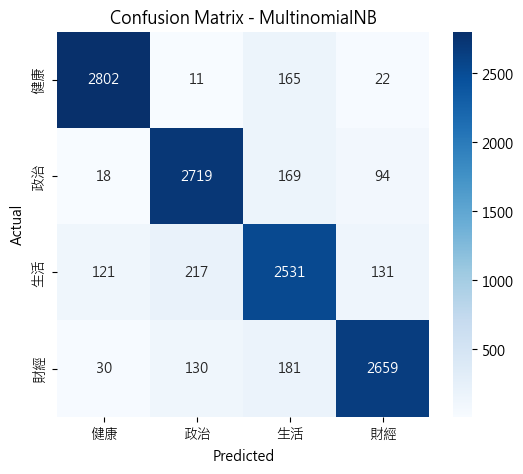

In [ ]:
train_and_evaluate_model(('MultinomialNB', 
                          MultinomialNB(alpha=0.2, fit_prior=True, class_prior=None)), 
                          X_train, y_train, X_test, y_test)
# alpha 越小 → 模型更容易對稀有詞過度自信 → 可能過擬合
# alpha 越大 → 平滑更強，對低頻特徵不敏感 → 降低過擬合

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

params = {'C': [4, 8, 10.0, 12, 15.0, 20.0]}
grid = GridSearchCV(LogisticRegression(solver='liblinear', penalty='l2', max_iter=200),
                    param_grid=params, cv=5)
grid.fit(X_train, y_train)

print("Best C:", grid.best_params_)
print("CV Accuracy:", grid.best_score_)


Best C: {'C': 8}
CV Accuracy: 0.8877499999999999


Model name: LogisticRegression
3-產生模型物件
4-模型物件開始進行訓練
5-模型儲存
6-模型載入
7-模型進行預估
8-模型進行評估
訓練的準確率
 0.9896785714285714
測試的準確率
 0.8939166666666667
分類報告
               precision    recall  f1-score   support

           0       0.96      0.92      0.94      3000
           1       0.90      0.89      0.89      3000
           2       0.82      0.86      0.84      3000
           3       0.90      0.91      0.90      3000

    accuracy                           0.89     12000
   macro avg       0.90      0.89      0.89     12000
weighted avg       0.90      0.89      0.89     12000

混淆矩陣
 [[2769   21  180   30]
 [  12 2663  211  114]
 [  85  191 2577  147]
 [  20   92  170 2718]]


<Figure size 800x600 with 0 Axes>

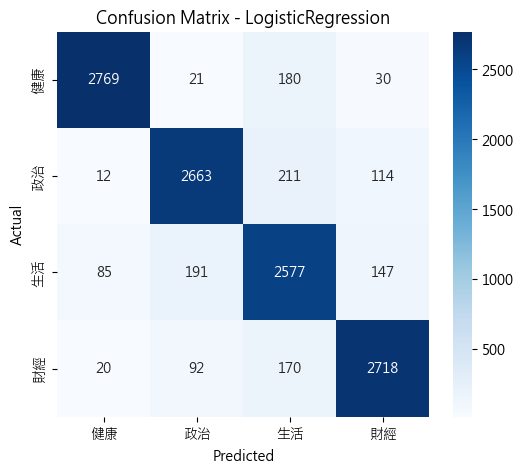

In [ ]:
train_and_evaluate_model(('LogisticRegression', 
                          LogisticRegression(penalty='l2', solver='liblinear', C=8.0)),
                          X_train, y_train, X_test, y_test)
# C 越小 → 正則化越強 → 過擬合風險降低
# C 越大 → 模型自由度高 → 容易過擬合
# l2 正則化 -> 降低過擬合

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB

# 將稀疏矩陣轉成 dense
X_train_dense = X_train.toarray()

params = {'var_smoothing': [1e-8, 1e-5, 1e-3, 0.1, 0.5, 1.0]}
grid = GridSearchCV(GaussianNB(), param_grid=params, cv=5)
grid.fit(X_train_dense, y_train)

print("Best var_smoothing:", grid.best_params_)
print("CV Accuracy:", grid.best_score_)

KeyboardInterrupt: 

Model name: GaussianNB
3-產生模型物件
4-模型物件開始進行訓練
5-模型儲存
6-模型載入
7-模型進行預估
8-模型進行評估
訓練的準確率
 0.9063214285714286
測試的準確率
 0.8595
分類報告
               precision    recall  f1-score   support

           0       0.83      0.96      0.89      3000
           1       0.87      0.90      0.88      3000
           2       0.89      0.66      0.76      3000
           3       0.86      0.91      0.88      3000

    accuracy                           0.86     12000
   macro avg       0.86      0.86      0.86     12000
weighted avg       0.86      0.86      0.86     12000

混淆矩陣
 [[2895    8   73   24]
 [  68 2698   81  153]
 [ 440  291 1984  285]
 [  82  102   79 2737]]


<Figure size 800x600 with 0 Axes>

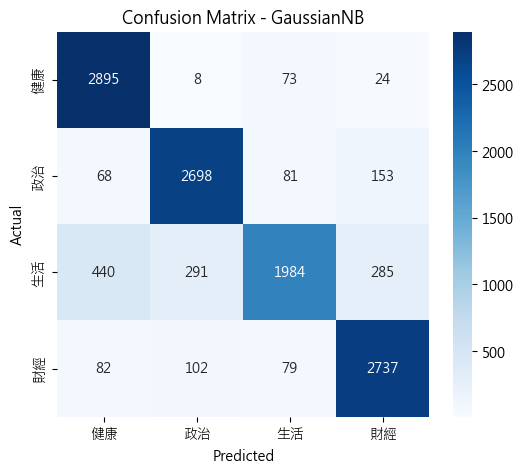

In [ ]:
train_and_evaluate_model(('GaussianNB', GaussianNB(var_smoothing=0.5)), X_train, y_train, X_test, y_test)
# var_smoothing 太小 → 可能數值不穩定、模型對少數樣本過度自信（過擬合）。
# var_smoothing 適中 → 模型更穩健，training/testing accuracy 都可能提高。

In [ ]:
# 該模型要跑比較久。
train_and_evaluate_model(('SVC_rbf', SVC(kernel='rbf', C=0.5, gamma='scale', probability=True)), 
                         X_train, y_train, X_test, y_test)

Model name: SVC_rbf
3-產生模型物件
4-模型物件開始進行訓練
5-模型儲存
6-模型載入
7-模型進行預估
8-模型進行評估
訓練的準確率
 0.9851851851851852
測試的準確率
 0.8567901234567902
分類報告
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       0.96      0.56      0.70        45
           2       1.00      1.00      1.00        45
           3       1.00      0.29      0.45        45
           4       1.00      0.87      0.93        45
           5       1.00      1.00      1.00        45
           6       0.44      1.00      0.61        45
           7       1.00      1.00      1.00        45
           8       1.00      1.00      1.00        45

    accuracy                           0.86       405
   macro avg       0.93      0.86      0.85       405
weighted avg       0.93      0.86      0.85       405

混淆矩陣
 [[45  0  0  0  0  0  0  0  0]
 [ 0 25  0  0  0  0 20  0  0]
 [ 0  0 45  0  0  0  0  0  0]
 [ 0  1  0 13  0  0 31  0  0]
 [ 0  0  0  0 39  0  6  0  0]
 [ 0 

In [ ]:
train_and_evaluate_model(('SVC_linear', SVC(kernel='linear', C=0.5, gamma='scale', probability=True)), 
                         X_train, y_train, X_test, y_test)

Model name: SVC_linear
3-產生模型物件
4-模型物件開始進行訓練
5-模型儲存
6-模型載入
7-模型進行預估
8-模型進行評估
訓練的準確率
 0.9957671957671957
測試的準確率
 0.9160493827160494
分類報告
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       0.92      0.76      0.83        45
           2       1.00      1.00      1.00        45
           3       0.93      0.62      0.75        45
           4       1.00      0.91      0.95        45
           5       1.00      1.00      1.00        45
           6       0.60      0.96      0.74        45
           7       1.00      1.00      1.00        45
           8       1.00      1.00      1.00        45

    accuracy                           0.92       405
   macro avg       0.94      0.92      0.92       405
weighted avg       0.94      0.92      0.92       405

混淆矩陣
 [[45  0  0  0  0  0  0  0  0]
 [ 0 34  0  0  0  0 11  0  0]
 [ 0  0 45  0  0  0  0  0  0]
 [ 0  1  0 28  0  0 16  0  0]
 [ 0  0  0  2 41  0  2  0  0]
 [

In [ ]:
train_and_evaluate_model(('DecisionTree2', DecisionTreeClassifier(max_depth=9)), X_train, y_train, X_test, y_test)

Model name: DecisionTree2
3-產生模型物件
4-模型物件開始進行訓練
5-模型儲存
6-模型載入
7-模型進行預估
8-模型進行評估
訓練的準確率
 0.5237884732276068
測試的準確率
 0.5235271367796829
分類報告
               precision    recall  f1-score   support

           0       0.90      0.28      0.42       625
           1       0.98      0.20      0.33      1495
           2       1.00      1.00      1.00       482
           3       0.29      1.00      0.45      1508
           4       1.00      0.17      0.29       477
           5       0.00      0.00      0.00        50
           6       1.00      0.10      0.18      1525
           7       1.00      1.00      1.00      1305
           8       0.70      0.22      0.33       290

    accuracy                           0.52      7757
   macro avg       0.76      0.44      0.45      7757
weighted avg       0.83      0.52      0.48      7757

混淆矩陣
 [[ 174    0    0  451    0    0    0    0    0]
 [   0  294    0 1174    0    0    0    0   27]
 [   0    0  482    0    0    0    0    0    0]
 [   

c:\Users\yjche\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\yjche\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\yjche\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

In [ ]:
train_and_evaluate_model(('DecisionTree1', DecisionTreeClassifier()), X_train, y_train, X_test, y_test)

Model name: DecisionTree1
3-產生模型物件
4-模型物件開始進行訓練


Model name: RandomForest
3-產生模型物件
4-模型物件開始進行訓練
5-模型儲存
6-模型載入
7-模型進行預估
8-模型進行評估
訓練的準確率
 0.8383928571428572
測試的準確率
 0.7870833333333334
分類報告
               precision    recall  f1-score   support

           0       0.94      0.83      0.88      3000
           1       0.87      0.75      0.81      3000
           2       0.59      0.86      0.70      3000
           3       0.87      0.71      0.79      3000

    accuracy                           0.79     12000
   macro avg       0.82      0.79      0.79     12000
weighted avg       0.82      0.79      0.79     12000

混淆矩陣
 [[2483   15  468   34]
 [  20 2249  581  150]
 [  94  208 2574  124]
 [  44  113  704 2139]]


<Figure size 800x600 with 0 Axes>

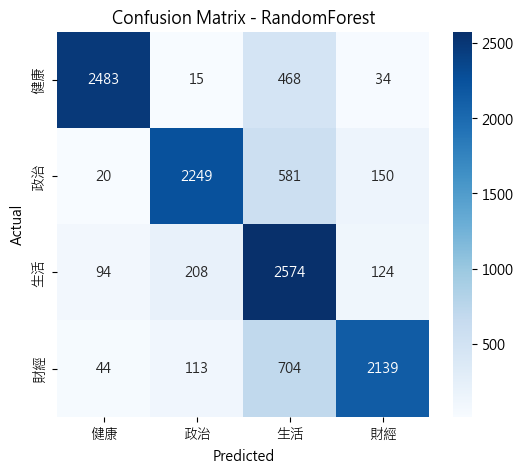

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 建立隨機森林分類器，可以調整 n_estimators（樹的數量）、max_depth 等超參數
rf_model = RandomForestClassifier(
    n_estimators=100,   # 樹的數量，預設 100
    max_depth=50,       # 樹的最大深度，None 表示不限制
    random_state=42,    # 設定隨機種子，確保結果可重現
    n_jobs=-1           # 使用全部 CPU 加速
)

train_and_evaluate_model(('RandomForest', rf_model), X_train, y_train, X_test, y_test)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

# 建立 KNN pipeline（自動標準化 + 模型）
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # 特徵標準化
    ('knn', KNeighborsClassifier(
        n_neighbors=10,    # 增加鄰居數，降低過擬合
        weights='uniform', # 使用均等權重
        metric='minkowski',# 歐氏距離
        p=2
    ))
])

# 使用你的 train_and_evaluate_model 函數
train_and_evaluate_model(('KNN', knn_pipeline), X_train, y_train, X_test, y_test)

Model name: KNN
3-產生模型物件
4-模型物件開始進行訓練
5-模型儲存
6-模型載入
7-模型進行預估


# 2. 

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from scipy.sparse import vstack

# X 是 csr_matrix，y 是 Series
df_y = pd.DataFrame({'class': y})

# 每個類別取 150 筆，保存索引
sampled_idx = df_y.groupby('class', group_keys=False).apply(lambda x: x.sample(150, random_state=42)).index

# 用稀疏矩陣的索引抽樣
X_subset = X[sampled_idx]
y_subset = y.iloc[sampled_idx]

# 分割時加 stratify
X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset, test_size=0.3, random_state=42, stratify=y_subset
)

print("X_train 型態:", type(X_train))  # <class 'scipy.sparse._csr.csr_matrix'>
print("X_train 形狀:", X_train.shape)
print("X_test 形狀:", X_test.shape)

print("\n各 class 在 y_train 的數量分布：")
print(y_train.value_counts().sort_index())

print("\n各 class 在 y_test 的數量分布：")
print(y_test.value_counts().sort_index())

X_train 型態: <class 'scipy.sparse._csr.csr_matrix'>
X_train 形狀: (945, 5000)
X_test 形狀: (405, 5000)

各 class 在 y_train 的數量分布：
label
0    105
1    105
2    105
3    105
4    105
5    105
6    105
7    105
8    105
Name: count, dtype: int64

各 class 在 y_test 的數量分布：
label
0    45
1    45
2    45
3    45
4    45
5    45
6    45
7    45
8    45
Name: count, dtype: int64


C:\Users\yjche\AppData\Local\Temp\ipykernel_10436\753042541.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_idx = df_y.groupby('class', group_keys=False).apply(lambda x: x.sample(150, random_state=42)).index


In [ ]:
import joblib
from scipy.sparse import issparse
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os

def train_and_evaluate_voting_model(model_tuple, X_train, y_train, X_test, y_test):
    """
    訓練、儲存、載入並評估 VotingClassifier 模型。

    Args:
        model_tuple (tuple): 包含模型名稱 (str) 和 VotingClassifier 物件的元組。
        X_train (array-like): 訓練資料的特徵。
        y_train (array-like): 訓練資料的標籤。
        X_test (array-like): 測試資料的特徵。
        y_test (array-like): 測試資料的標籤。
    """
    model_name = model_tuple[0]
    model = model_tuple[1]

    print('model name:', model_name)
    print('3-產生模型物件')

    print('4-模型物件開始進行訓練')
    #model.fit(X_train, y_train)
    if issparse(X_train):
        X_train_dense = X_train.toarray()
        model.fit(X_train_dense, y_train)
    else:
        model.fit(X_train, y_train)

    print('5-模型儲存')
    # 設定儲存路徑和檔案名
    output_dir = 'model_files'
    filename = f'{model_name}.pkl'
    filepath = os.path.join(output_dir, filename)
    # 檢查目錄是否存在，如果不存在則創建
    os.makedirs(output_dir, exist_ok=True)

    joblib.dump(model, filepath)  # filename
    print('6-模型載入')
    loaded_model = joblib.load(filepath)

    print('7-模型進行預估')
    # predict1 = loaded_model.predict(X_test)
    # predict2 = loaded_model.predict(X_train)
    # 將稀疏矩陣轉換為稠密矩陣
    if issparse(X_test):
        X_test_dense = X_test.toarray()
        predict1 = loaded_model.predict(X_test_dense)
    else:
        predict1 = loaded_model.predict(X_test)

    # 訓練集的預估也需要轉換（雖然錯誤通常出現在測試集）
    if issparse(X_train):
        predict2 = loaded_model.predict(X_train.toarray())
    else:
        predict2 = loaded_model.predict(X_train)

    print('8-模型進行評估')
    print('訓練的準確率\n', accuracy_score(y_train, predict2))
    print('測試的準確率\n', accuracy_score(y_test, predict1))
    print('分類報告\n', classification_report(y_test, predict1))
    print('混淆矩陣\n', confusion_matrix(y_test, predict1))
    print('-' * 30) # 添加分隔線以區分不同模型的輸出

# VotingClassifier 模型列表
clf_list2 = [('hard vote', VotingClassifier(clf_list, voting='hard')),
             ('soft vote', VotingClassifier(clf_list, voting='soft'))]

# 使用 for 迴圈逐次將 clf_list2 中的元素作為輸入資料帶入函數
# for model_info in clf_list2:
#     train_and_evaluate_voting_model(model_info, X_train, y_train, X_test, y_test)

In [ ]:
train_and_evaluate_voting_model(('hard vote', VotingClassifier(clf_list, voting='hard')),
                                 X_train, y_train, X_test, y_test)

model name: hard vote
3-產生模型物件
4-模型物件開始進行訓練
5-模型儲存
6-模型載入
7-模型進行預估
8-模型進行評估
訓練的準確率
 0.9989417989417989
測試的準確率
 0.9358024691358025
分類報告
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       0.79      0.82      0.80        45
           2       1.00      1.00      1.00        45
           3       0.85      0.78      0.81        45
           4       1.00      1.00      1.00        45
           5       1.00      1.00      1.00        45
           6       0.79      0.82      0.80        45
           7       1.00      1.00      1.00        45
           8       1.00      1.00      1.00        45

    accuracy                           0.94       405
   macro avg       0.94      0.94      0.94       405
weighted avg       0.94      0.94      0.94       405

混淆矩陣
 [[45  0  0  0  0  0  0  0  0]
 [ 0 37  0  2  0  0  6  0  0]
 [ 0  0 45  0  0  0  0  0  0]
 [ 0  6  0 35  0  0  4  0  0]
 [ 0  0  0  0 45  0  0  0  0]
 [ 

In [ ]:
train_and_evaluate_voting_model(('soft vote', VotingClassifier(clf_list, voting='soft')),
                                 X_train, y_train, X_test, y_test)

model name: soft vote
3-產生模型物件
4-模型物件開始進行訓練
5-模型儲存
6-模型載入
7-模型進行預估
8-模型進行評估
訓練的準確率
 0.9989417989417989
測試的準確率
 0.9407407407407408
分類報告
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       0.83      0.84      0.84        45
           2       1.00      1.00      1.00        45
           3       0.80      0.80      0.80        45
           4       0.98      1.00      0.99        45
           5       0.98      1.00      0.99        45
           6       0.88      0.82      0.85        45
           7       1.00      1.00      1.00        45
           8       1.00      1.00      1.00        45

    accuracy                           0.94       405
   macro avg       0.94      0.94      0.94       405
weighted avg       0.94      0.94      0.94       405

混淆矩陣
 [[45  0  0  0  0  0  0  0  0]
 [ 0 38  0  4  0  1  2  0  0]
 [ 0  0 45  0  0  0  0  0  0]
 [ 0  5  0 36  1  0  3  0  0]
 [ 0  0  0  0 45  0  0  0  0]
 [ 